# ESC SPMe: Plot I, V, T, and SOC for all cells

Note to self: currently set up to plot "fit" using 100A params with data input to illustrate error from using  wrong parameters  vs error propagation 

Conclusions: Because the model overpredicts current, I also let it overpredict temperature as opposed to tuning Cp and h to fit the data. Using the lumped thermal model, we see that the effect of decomposition heating is minimal, which was expected. SEI decomposition is also the only decomp reaction contributing to heating which was expected.  

In [6]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, constants
import matplotlib as mpl
from scipy.interpolate import interp2d
from matplotlib import cm

import pybamm
print(pybamm.__path__[0])
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)
# pybamm.settings.max_smoothing = 'exact'

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


In [7]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

## Define parameter functions

In [28]:
from pybamm import exp, constants, Parameter


def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9
    return D_ref*k #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    # E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    return D_ref *k #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )

#arrhenius

def modified_graphite_diffusivity_PeymanMPM_arr(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref*k*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM_arr(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref *k *arrhenius

def modified_electrolyte_diffusivity_PeymanMPM_arr(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    E_D_e = 37040
    arrhenius = exp(E_D_e / constants.R * (1 / 298.15 - 1 / T))
    return D_c_e*arrhenius

def modified_electrolyte_conductivity_PeymanMPM_arr(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    arrhenius = exp(E_k_e / constants.R * (1 / 298.15 - 1 / T))
    return sigma_e*arrhenius


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM_arr(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 * arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM_arr(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 *arrhenius
    )



In [29]:
Q_nom = 4.6
t_end = 5*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    # T_amb = np.mean(raw_data['Cell Temperature'][(raw_da ta.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force', 'CO2 from CAN (ppm)']].loc[esc_start:esc_end].copy()
    data['Cell Temperature2'] = data['Cell Temperature'].copy() #make a copy 
    data['Cell Temperature'][data['Cell Temperature']>140] = None #filter and interpolate original
    data.interpolate(inplace=True) #fill in nans for df
    data['Cell Temperature2'][data['Cell Temperature2']>140] = None #filter copy, NO interp
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = data['Force']*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F','CO2', 'Temp2']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    # data['CO2'] = data.
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0


data,T_amb_0 = load_data(1, '100A')

## SPMe ESC simulations

In [30]:
param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }
param_update_arr = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM_arr,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM_arr,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM_arr,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM_arr,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM_arr,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM_arr,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }

In [16]:
def sim_ESC(SOC_0=1, SOC_name = '100A', params = {}, SOC_param = "100A", k_h_sei = 1, T_amb = 25, t_end=10*60):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    R_ext = pybamm.Parameter("External resistance [Ohm]")

    Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
    hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
    R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
    R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}
    k_A_sei  = {'100A': 0.13210066, '100B': 0.320855, '75': 0.06343707, '50':0.08423777}# k_A = 0.05716926 (MSE 1e-8 50%), k_A = 0.04571944 (MSE 1e-8 75%), k_A = 0.07912785(MSE 1e-8 100% t<80s), k_A = 0.238155 (MSE 1e-8 100F% t<53s)

    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
        # "loss of active material": "electrolyte dryout", 
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        # "Initial fraction of Li in SEI": 0.15,
        "Frequency factor for SEI decomposition [s-1]": 1.67E15*k_A_sei[SOC_param],
        "Enthalpy of SEI decomposition [J.kg-1]":257000*k_h_sei,
        # "Number of electrodes connected in parallel to make a cell": 10,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_name],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_name], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb + 273.15,
        "Initial temperature [K]": T_amb + 273.15,
        "Initial cell compression stress [kPa]": 15/param['Active material surface area [m2]']/1000,
        "Total heat transfer coefficient [W.m-2.K-1]":hs[SOC_param],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
    }, check_already_exists = False)

    param.update(params, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe") #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) # var_pts=var_pts
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution

# solution = sim_ESC(0.75)


### Plot: SPMe trends

#### Effect of external resistance

In [115]:
solutions_r = []
R_sweeps = [0.0025, 0.005] + list(np.arange(0.01,0.11,0.01))#[0.1, 0.05, 0.04, 0.03,0.02, 0.01]
R_sweeps.reverse()

for R in R_sweeps: 
    # print('R = ' + str(R))
    param_update_iso.update({
        "External short resistance [Ohm]": R,
    })
    solution_r= sim_ESC(1, params = param_update_iso)
    solutions_r.append(solution_r)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


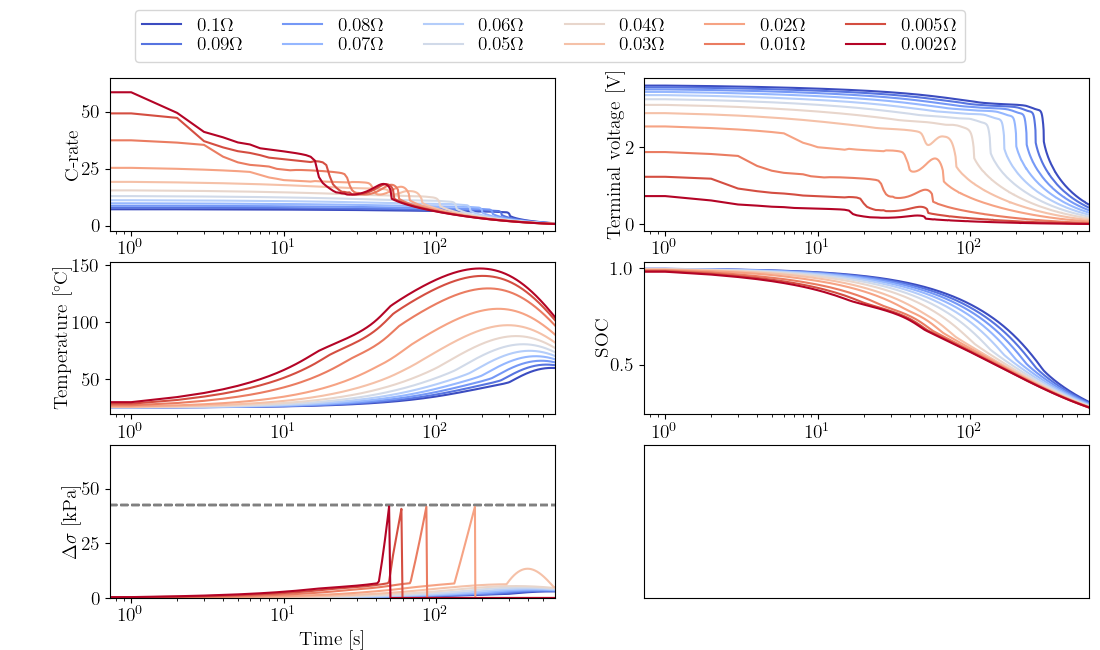

,R_esc,SOC_f,t_discharge,max_sigma,max_T_list
0,0.1000,0.499522,283.0,3.024623,59.732508
1,0.0900,0.499620,259.0,3.278042,62.642584
2,0.0800,0.498803,237.0,3.572688,66.026087
3,0.0700,0.498986,218.0,3.919262,70.005877
4,0.0600,0.499111,201.0,4.332636,74.752755
5,0.0500,0.499059,186.0,4.833969,80.509697
6,0.0400,0.498961,173.0,5.457611,87.671135
7,0.0300,0.499619,162.0,13.398177,97.212245
8,0.0200,0.499822,156.0,41.834013,111.599754
9,0.0100,0.499487,151.0,41.803516,129.489785


In [99]:
plt.rcParams.update({'font.size': 14})
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = [str(np.round(R,3)) + '$\Omega$' for R in R_sweeps]
fig, ax = plt.subplots(3,  2, figsize=(11, 6.5))#, constrained_layout=True gridspec_kw = {'wspace':0.3, 'hspace':0.1}
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.99, top=0.88, wspace=0.2, hspace=0.2)

ax = ax.flatten()
linestyles = ['-'] #['--',':','-.']*5

cmap = plt.cm.get_cmap('coolwarm', len(R_sweeps))
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []

# for each R..
for i, solution in enumerate(solutions_r):    
    # plot
    t = solution["Time [s]"].entries
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    sim_color = sim_colors[i]
    sim_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,

    I = solution['C-rate'](t)
    ax[0].semilogx(x_plot, I, linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
    ax[0].set_ylabel('C-rate', labelpad=0)
    ax[0].set_xlim([min(t),max(t)])

    V = solution['Terminal voltage [V]']
    ax[1].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
    ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
    ax[1].set_xlim([min(t),max(t)])

    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax[2].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
    ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax[2].set_xlim([min(t),max(t)])

        
    soc = 1 - integrate.cumtrapz(I,t)/3600
    soc = np.insert(soc,0,1)
    ax[3].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
    ax[3].set_ylabel('SOC',labelpad=-1)
    ax[3].set_xlim([min(t),max(t)])

    sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
        t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
    

    discharge_end = np.where(soc<0.5)[0][0]
    soc_f = soc[discharge_end]
    t_discharge = t[discharge_end]
    max_T = max(T)
    max_sigma = max(sigma_plot)

    Resc_list.append(R)
    soc_f_list.append(soc_f)
    t_discharge_list.append(t_discharge)
    max_sigma_list.append(max_sigma)
    max_T_list.append(max_T)
    
    ax[4].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'grey') #(out.P_est-P_atm)/1000-sigma_0/1000
    ax[4].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax[4].set_ylim([0,70])
    ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax[4].set_xlabel(xlabel)
    ax[4].set_xlim([min(t),max(t)])



# Last empty plot: Hide axes label and tick marks
ax[-1].set_xlim(ax[-2].get_xlim())
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_yticks([])
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_xticks([])#ax[-2].get_xticks()


# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=6, labelspacing = 0.1) #,  bbox_to_anchor=(0.5, 0.88),prop={'size': 10}
plt.xlim([0,t[-1]])
# plt.tight_layout()
plt.savefig('./figs/R_sweep_log.eps', format='eps', dpi = 300)
plt.savefig('./figs/R_sweep_log.jpg', format='jpg', dpi = 300)

plt.show()

df = pd.DataFrame(list(zip(R_sweeps,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
                  columns= ['R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
display(df)
plt.rcParams.update({'font.size': 9})


#### Effect of h

In [123]:
solutions_h = []
h_sweeps = list(np.arange(15,60,5)) #34.8 nominal
h_sweeps.reverse()

for h in h_sweeps: 
    # print('h = ' + str(h))
    param_update_iso.update({
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "External short resistance [Ohm]":0.03,
    })
    solution_h= sim_ESC(1, params = param_update_iso)
    solutions_h.append(solution_h)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


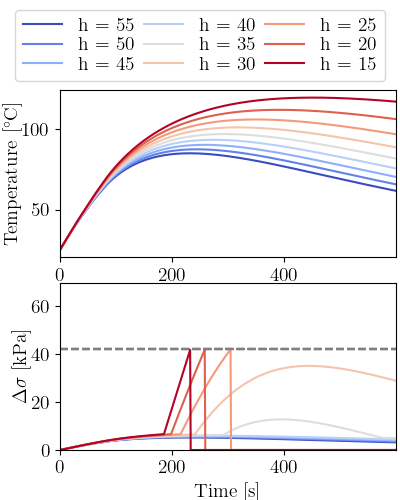

,h,max_sigma,max_T_list
0,55,5.234071,85.104159
1,50,5.450599,87.590611
2,45,5.692377,90.367010
3,40,5.965479,93.503113
4,35,12.799848,97.088108
5,30,35.173537,101.246989
6,25,42.045089,106.171158
7,20,41.905735,112.165122
8,15,41.874816,119.772731


In [127]:
plt.rcParams.update({'font.size': 14})
param = pybamm.ParameterValues('Tran2023')
sim_set_labels = ['h = ' + str(h) for h in h_sweeps]
fig, ax = plt.subplots(2,  1, figsize=(4,5))#, constrained_layout=True gridspec_kw = {'wspace':0.3, 'hspace':0.1}
plt.subplots_adjust(left=0.15, bottom=0.1, right=0.99, top=0.82, wspace=0.2, hspace=0.15)

axs = ax.flatten()
linestyles = ['-'] #['--',':','-.']*5

cmap = plt.cm.get_cmap('coolwarm', len(h_sweeps))
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

h_list = []
Resc_list =[]
# soc_f_list = []
# t_discharge_list = []
max_sigma_list = []
max_T_list = []

# for each h..
for i, solution in enumerate(solutions_h):    
    # plot
    t = solution["Time [s]"].entries
    # discharge_end = np.where(soc<0.5)[0][0]
    x = solution["x [m]"].entries[:, 0]
    x_plot = t
    xlabel = "Time [s]"
    sim_color = sim_colors[i]
    sim_ls = linestyles[0]

    sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,

    ax = axs[0]
    T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
    ax.plot(x_plot, T,linestyle=sim_ls, color = sim_color,label=sim_set_labels[i])  
    ax.set_ylabel('Temperature [$^\circ$C]',labelpad=0)
    ax.set_xlim([min(t),max(t)])

    sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
    sigma = solution["Cell expansion stress [kPa]"].entries
    sigma_plot = sigma.copy()
    vent_check = np.argmax(sigma_plot>sigma_max)
    if vent_check > 0:
        sigma_plot[vent_check::] = 0  
        t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
    

    # discharge_end = np.where(soc<0.5)[0][0]
    # soc_f = soc[discharge_end]
    # t_discharge = t[discharge_end]
    max_T = max(T)
    max_sigma = max(sigma_plot)

    Resc_list.append(R)
    soc_f_list.append(soc_f)
    t_discharge_list.append(t_discharge)
    max_sigma_list.append(max_sigma)
    max_T_list.append(max_T)
    
    ax = axs[1]
    ax.plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'grey') #(out.P_est-P_atm)/1000-sigma_0/1000
    ax.plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
    ax.set_ylim([0,70])
    ax.set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
    ax.set_xlabel(xlabel)
    ax.set_xlim([min(t),max(t)])



# # Last empty plot: Hide axes label and tick marks
# ax = axs[-1] 
# ax.set_xlim(axs[-2].get_xlim())
# ax.yaxis.set_tick_params(labelleft=False)
# ax.set_yticks([])
# ax.yaxis.set_tick_params(labelleft=False)
# ax.set_xticks([])#ax[-2].get_xticks()


# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, labelspacing = 0.1, columnspacing=0.5) #,  bbox_to_anchor=(0.5, 0.88),prop={'size': 10}
plt.xlim([0,t[-1]])
plt.savefig('./figs/h_sweep_log.eps', format='eps', dpi = 300)
plt.savefig('./figs/h_sweep_log.jpg', format='jpg', dpi = 300)

plt.show()

df = pd.DataFrame(list(zip(h_sweeps, max_sigma_list, max_T_list)), 
                  columns= ['h','max_sigma', 'max_T_list'])
display(df)
plt.rcParams.update({'font.size': 9})


#### Effect of $R_{ESC}$ and $h$

In [10]:
# solutions_list=[]
# h_sweeps = list(np.arange(0,60,5)) #34.8 nominal
# h_sweeps.reverse()
# # R_sweeps = [0.0025, 0.005] + list(np.arange(0.01,0.11,0.01))#[0.1, 0.05, 0.04, 0.03,0.02, 0.01]
# R_sweeps = [0.001, 0.0025, 0.005] + list(np.arange(0.01,0.11,0.005))#[0.1, 0.05, 0.04, 0.03,0.02, 0.01]
# R_sweeps.reverse()


# h_list = []
# Resc_list =[]
# soc_f_list = []
# t_discharge_list = []
# max_sigma_list = []
# max_T_list = []

# for h in h_sweeps: 
#     solutions = []
#     for R in R_sweeps: 
#         # print('R = ' + str(R))
#         param_update_iso.update({
#             "External short resistance [Ohm]": R,
#             "Total heat transfer coefficient [W.m-2.K-1]":h,
#         })
#         solution= sim_ESC(1, params = param_update_iso)
#         solutions.append(solution)

#         # CALCULATE METRICS
#         t = solution["Time [s]"].entries
#         I = solution['C-rate'](t)

#         # calculate final soc
#         SOC_0 = 1
#         soc = SOC_0 - integrate.cumtrapz(I,t)/3600
#         soc = np.insert(soc,0,SOC_0)
#         soc_f = soc[discharge_end]
#         discharge_end = np.where(soc<0.5)[0][0]

#         # calculate discharge time  
#         t_discharge = t[discharge_end]

#         # max sigma
#         sigma_max = 42.35277961 # from either 100A%
#         sigma = solution["Cell expansion stress [kPa]"].entries
#         sigma_plot = sigma.copy()
#         vent_check = np.argmax(sigma_plot>sigma_max)
#         if vent_check > 0:
#             sigma_plot[vent_check::] = 0  
#         max_sigma = max(sigma_plot)

#         # max_T
#         T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
#         max_T = max(T)
        
#         h_list.append(h)
#         Resc_list.append(R)
#         soc_f_list.append(soc_f)
#         t_discharge_list.append(t_discharge)
#         max_sigma_list.append(max_sigma)
#         max_T_list.append(max_T)

#         solutions.append(solution)
#     solutions_list.append(solutions)

# df = pd.DataFrame(list(zip(h_list,Resc_list,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
#                   columns= ['h', 'R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
# df.to_pickle('R_h_sweep.pkl')

# load from previous sims
df = pd.read_pickle('R_h_sweep.pkl')
R_sweeps = np.unique(df.R_esc)
h_sweeps = np.unique(df.h)
display(df)


,h,R_esc,SOC_f,t_discharge,max_sigma,max_T_list
0,55,0.1050,0.726740,295.0,2.236796,50.685690
1,55,0.1000,0.479993,283.0,2.333919,51.800983
2,55,0.0950,0.479821,271.0,2.438785,53.005189
3,55,0.0900,0.481077,259.0,2.552022,54.305520
4,55,0.0850,0.483166,247.0,2.674732,55.714628
...,...,...,...,...,...,...
271,0,0.0150,0.496468,154.0,41.021802,199.927879
272,0,0.0100,0.495948,151.0,39.307133,214.617651
273,0,0.0050,0.495114,147.0,41.590238,231.312251
274,0,0.0025,0.498308,146.0,41.568328,240.970235


C:\Users\Vivian\AppData\Local\Temp\ipykernel_1076\2563637096.py:14: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f = interp2d(h_sweeps, R_sweeps, Z ,kind='linear') #kind = {‘linear’(default), ‘cubic’, ‘quintic’}
C:\Users\Vivian\AppData\Local\Temp\ipykernel_1076\2563637096.py:17: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, f

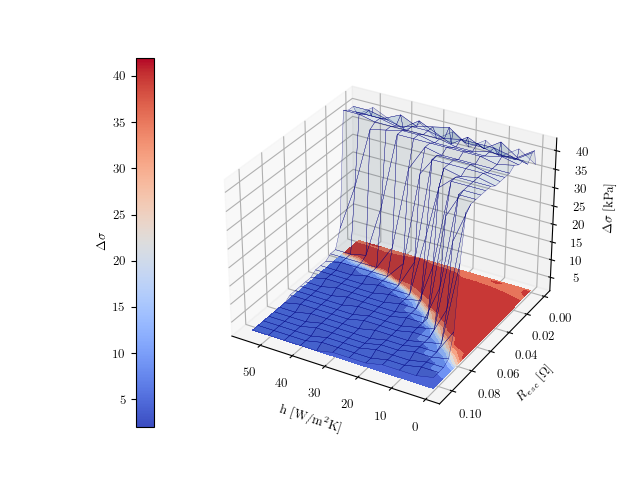

In [11]:
ax = plt.figure().add_subplot(projection='3d')
X, Y = np.meshgrid(h_sweeps, R_sweeps)
Z = X.copy()
# make Z from df
for i, h in enumerate(h_sweeps):
    for j, r in enumerate(R_sweeps): 
        Z[j][i] = df.max_sigma[(df.h == h) & (df.R_esc == r)]

# interpolate
num_pts = 50
X1, Y1 = np.meshgrid(np.linspace(min(h_sweeps), max(h_sweeps), num_pts), np.linspace(min(R_sweeps), max(R_sweeps), num_pts))
x1 = np.linspace(min(h_sweeps), max(h_sweeps), num_pts)
y1 = np.linspace(min(R_sweeps), max(R_sweeps),num_pts)
f = interp2d(h_sweeps, R_sweeps, Z ,kind='linear') #kind = {‘linear’(default), ‘cubic’, ‘quintic’}
# f = interp2d(h_sweep, R_sweep, Z, kind='cubic') #

Z1 = f(x1, y1)

# Plot the 3D surface
# ax.plot_surface(X, Y, Z,cmap=cm.coolwarm, linewidth=0) 
# ax.plot_surface(X1, Y1, Z1,cmap=cm.coolwarm, linewidth=0) # interpolated

# plot wire surface and projections on each "wall"
ax.plot_surface(X, Y, Z, edgecolor='navy',lw=0.2, alpha=0.1) 
ax.contourf(X, Y, Z, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm')
# ax.contourf(X, Y, Z, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
# ax.contourf(X, Y, Z, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

# ax.plot_surface(X1, Y1, Z1, edgecolor='navy',lw=0.05, alpha=0) 
# ax.contourf(X1, Y1, Z1, zdir='z', offset=ax.get_zlim()[0], cmap='coolwarm') #RdYlBu, RdYlGn
# ax.contourf(X1, Y1, Z1, zdir='x', offset=ax.get_xlim()[0], cmap='coolwarm')
# ax.contourf(X1, Y1, Z1, zdir='y', offset=ax.get_ylim()[0], cmap='coolwarm')

m = cm.ScalarMappable(cmap='coolwarm')
m.set_array(Z)
plt.colorbar(m, location = 'left',label = "$\Delta \sigma$") #, shrink=0.6
ax.set(xlabel='h [W/m$^2$K]', ylabel='$R_{esc}$  [$\Omega$]', zlabel='$\Delta\sigma$ [kPa]') #xlim=(-40, 40), ylim=(-40, 40), zlim=(-100, 100), 
ax.view_init(30, 120)
plt.savefig('./figs/R_h_sigma_sweep.eps', format='eps', dpi = 300)
plt.savefig('./figs/R_h_sigma_sweep.jpg', format='jpg', dpi = 300)

plt.show()

#### Effect of Arrhenius-dependencies

In [38]:
solutions_r_iso = []
solutions_r_arr = []

R_sweeps = [0.016] + list(np.arange(0.02,0.11,0.01))#[0.0025, 0.005] + [0.1, 0.05, 0.04, 0.03,0.02, 0.01]
R_sweeps.reverse()

for R in R_sweeps: 
    print('R = ' + str(R))
    # sim isothermal 
    param_update_iso.update({
        "External short resistance [Ohm]": R,
    })
    solution_r_iso= sim_ESC(1, params = param_update_iso)
    solutions_r_iso.append(solution_r_iso)

    # sim arrhenius-dependencies
    param_update_arr.update({
        "External short resistance [Ohm]": R,
    })    
    solution_r_arr= sim_ESC(1, params = param_update_arr)
    solutions_r_arr.append(solution_r_arr)


R = 0.09999999999999999
R = 0.09
R = 0.07999999999999999
R = 0.06999999999999999
R = 0.06
R = 0.049999999999999996
R = 0.039999999999999994
R = 0.03
R = 0.02
R = 0.016


At t = 0 and h = 4.63605e-013, the error test failed repeatedly or with |h| = hmin.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


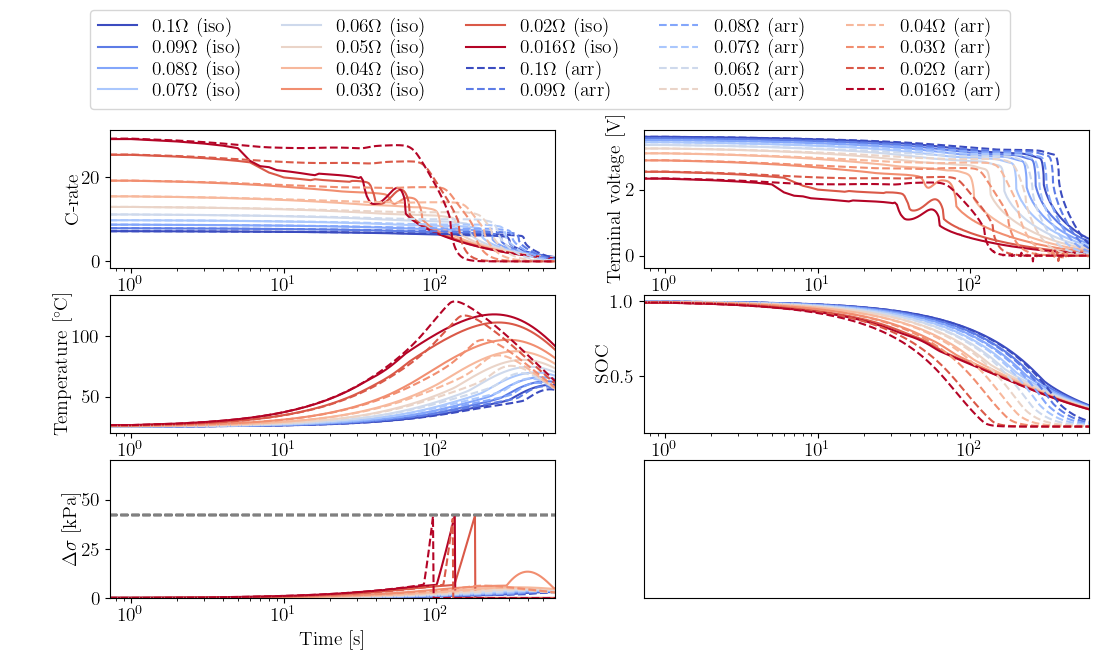

,R_esc,SOC_f,t_discharge,max_sigma,max_T_list
0,0.100,0.499522,283.0,3.024623,59.732508
1,0.090,0.499620,259.0,3.278042,62.642584
2,0.080,0.498803,237.0,3.572688,66.026087
3,0.070,0.498986,218.0,3.919262,70.005877
4,0.060,0.499111,201.0,4.332636,74.752755
5,0.050,0.499059,186.0,4.833969,80.509697
6,0.040,0.498961,173.0,5.457625,87.671294
7,0.030,0.499619,162.0,13.398177,97.212245
8,0.020,0.499822,156.0,41.834013,111.599754
9,0.016,0.499570,154.0,41.997770,118.340994


In [48]:
plt.rcParams.update({'font.size': 14})
param = pybamm.ParameterValues('Tran2023')
fig, ax = plt.subplots(3,  2, figsize=(11, 6.5))#, constrained_layout=True gridspec_kw = {'wspace':0.3, 'hspace':0.1}
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.99, top=0.8, wspace=0.2, hspace=0.2)

ax = ax.flatten()
linestyles = ['-', '--',':','-.']

cmap = plt.cm.get_cmap('coolwarm', len(R_sweeps))
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []

# for each R..
for j,solutions in enumerate([solutions_r_iso,solutions_r_arr]):
    if j==0:
        sim_set_labels = [str(np.round(R,3)) + '$\Omega$ (iso)' for R in R_sweeps]
    else:
        sim_set_labels=[str(np.round(R,3)) + '$\Omega$ (arr)' for R in R_sweeps]
        
    for i, solution in enumerate(solutions):    
        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        sim_color = sim_colors[i]
        sim_ls = linestyles[j]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,

        I = solution['C-rate'](t)
        ax[0].semilogx(x_plot, I, linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
        ax[0].set_ylabel('C-rate', labelpad=0)
        ax[0].set_xlim([min(t),max(t)])

        V = solution['Terminal voltage [V]']
        ax[1].semilogx(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1].set_xlim([min(t),max(t)])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2].semilogx(x_plot, T,linestyle=sim_ls, color = sim_color)  
        ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2].set_xlim([min(t),max(t)])

            
        soc = 1 - integrate.cumtrapz(I,t)/3600
        soc = np.insert(soc,0,1)
        ax[3].semilogx(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        ax[3].set_ylabel('SOC',labelpad=-1)
        ax[3].set_xlim([min(t),max(t)])

        sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
        

        discharge_end = np.where(soc<0.5)[0][0]
        soc_f = soc[discharge_end]
        t_discharge = t[discharge_end]
        max_T = max(T)
        max_sigma = max(sigma_plot)

        Resc_list.append(R)
        soc_f_list.append(soc_f)
        t_discharge_list.append(t_discharge)
        max_sigma_list.append(max_sigma)
        max_T_list.append(max_T)
        
        ax[4].semilogx([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'grey') #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4].semilogx(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4].set_ylim([0,70])
        ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4].set_xlabel(xlabel)
        ax[4].set_xlim([min(t),max(t)])



# Last empty plot: Hide axes label and tick marks
ax[-1].set_xlim(ax[-2].get_xlim())
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_yticks([])
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_xticks([])#ax[-2].get_xticks()


# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=5, labelspacing = 0.1) #,  bbox_to_anchor=(0.5, 0.88),prop={'size': 10}
plt.xlim([0,t[-1]])
# plt.tight_layout()
plt.savefig('./figs/R_sweep_log.eps', format='eps', dpi = 300)
plt.savefig('./figs/R_sweep_log.jpg', format='jpg', dpi = 300)

plt.show()

df = pd.DataFrame(list(zip(R_sweeps,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
                  columns= ['R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
display(df)
plt.rcParams.update({'font.size': 9})


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


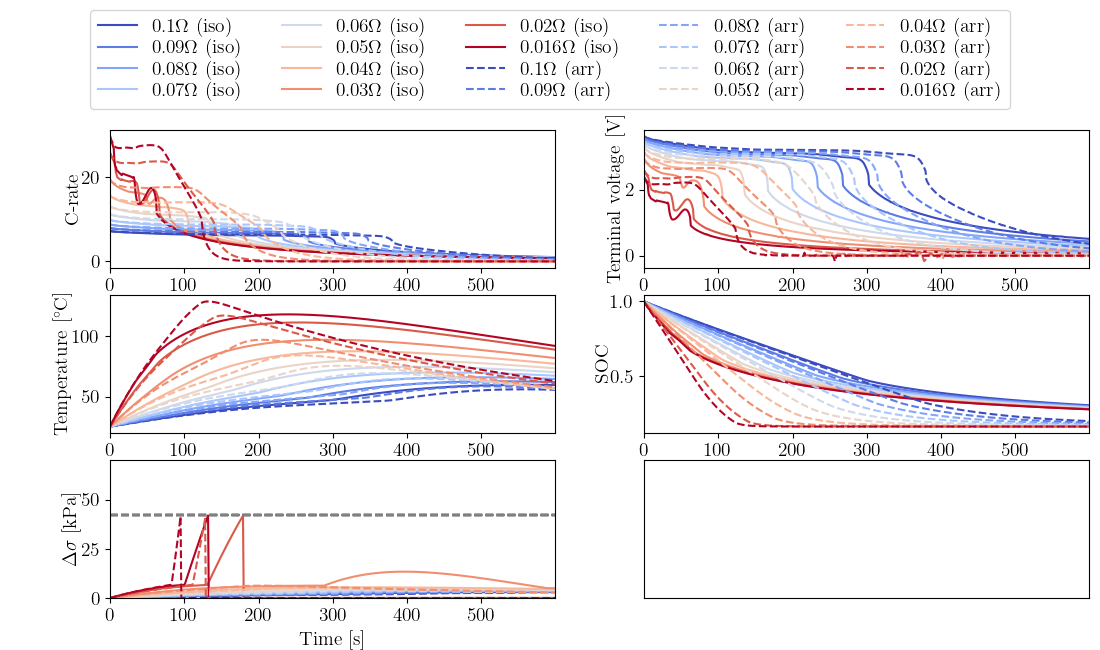

,R_esc,SOC_f,t_discharge,max_sigma,max_T_list
0,0.100,0.499522,283.0,3.024623,59.732508
1,0.090,0.499620,259.0,3.278042,62.642584
2,0.080,0.498803,237.0,3.572688,66.026087
3,0.070,0.498986,218.0,3.919262,70.005877
4,0.060,0.499111,201.0,4.332636,74.752755
5,0.050,0.499059,186.0,4.833969,80.509697
6,0.040,0.498961,173.0,5.457625,87.671294
7,0.030,0.499619,162.0,13.398177,97.212245
8,0.020,0.499822,156.0,41.834013,111.599754
9,0.016,0.499570,154.0,41.997770,118.340994


In [50]:
plt.rcParams.update({'font.size': 14})
param = pybamm.ParameterValues('Tran2023')
fig, ax = plt.subplots(3,  2, figsize=(11, 6.5))#, constrained_layout=True gridspec_kw = {'wspace':0.3, 'hspace':0.1}
plt.subplots_adjust(left=0.1, bottom=0.08, right=0.99, top=0.8, wspace=0.2, hspace=0.2)

ax = ax.flatten()
linestyles = ['-', '--',':','-.']

cmap = plt.cm.get_cmap('coolwarm', len(R_sweeps))
sim_colors = [mpl.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]

h_list = []
Resc_list =[]
soc_f_list = []
t_discharge_list = []
max_sigma_list = []
max_T_list = []

# for each R..
for j,solutions in enumerate([solutions_r_iso,solutions_r_arr]):
    if j==0:
        sim_set_labels = [str(np.round(R,3)) + '$\Omega$ (iso)' for R in R_sweeps]
    else:
        sim_set_labels=[str(np.round(R,3)) + '$\Omega$ (arr)' for R in R_sweeps]
        
    for i, solution in enumerate(solutions):    
        # plot
        t = solution["Time [s]"].entries
        x = solution["x [m]"].entries[:, 0]
        x_plot = t
        xlabel = "Time [s]"
        sim_color = sim_colors[i]
        sim_ls = linestyles[j]

        sigma_0 = data['F'].iloc[0]/param['Active material surface area [m2]']/1000,

        I = solution['C-rate'](t)
        ax[0].plot(x_plot, I, linestyle=sim_ls, color = sim_color, label=sim_set_labels[i])
        ax[0].set_ylabel('C-rate', labelpad=0)
        ax[0].set_xlim([min(t),max(t)])

        V = solution['Terminal voltage [V]']
        ax[1].plot(x_plot, V(t),linestyle=sim_ls, color = sim_color)
        ax[1].set_ylabel('Terminal voltage [V]', labelpad=0)
        ax[1].set_xlim([min(t),max(t)])

        T = solution['Volume-averaged cell temperature [K]'].entries - 273.15
        ax[2].plot(x_plot, T,linestyle=sim_ls, color = sim_color)  
        ax[2].set_ylabel('Temperature [$^\circ$C]',labelpad=0)
        ax[2].set_xlim([min(t),max(t)])

            
        soc = 1 - integrate.cumtrapz(I,t)/3600
        soc = np.insert(soc,0,1)
        ax[3].plot(x_plot, soc,linestyle=sim_ls, color = sim_color)  # can evaluate at arbitrary x (single representative particle)
        ax[3].set_ylabel('SOC',labelpad=-1)
        ax[3].set_xlim([min(t),max(t)])

        sigma_max = 42.35277961 # from either 100% (default) or 100%F cell
        sigma = solution["Cell expansion stress [kPa]"].entries
        sigma_plot = sigma.copy()
        vent_check = np.argmax(sigma_plot>sigma_max)
        if vent_check > 0:
            sigma_plot[vent_check::] = 0  
            t_vent_sim = data.t[np.where(sigma_plot==0)[0][0]]
        

        discharge_end = np.where(soc<0.5)[0][0]
        soc_f = soc[discharge_end]
        t_discharge = t[discharge_end]
        max_T = max(T)
        max_sigma = max(sigma_plot)

        Resc_list.append(R)
        soc_f_list.append(soc_f)
        t_discharge_list.append(t_discharge)
        max_sigma_list.append(max_sigma)
        max_T_list.append(max_T)
        
        ax[4].plot([x_plot[0], x_plot[-1]], sigma_max*np.array([1,1]) , linestyle='--', color = 'grey') #(out.P_est-P_atm)/1000-sigma_0/1000
        ax[4].plot(x_plot, sigma_plot,linestyle=sim_ls, color = sim_color)
        ax[4].set_ylim([0,70])
        ax[4].set_ylabel("$\Delta \sigma$ [kPa]",labelpad=0)
        ax[4].set_xlabel(xlabel)
        ax[4].set_xlim([min(t),max(t)])



# Last empty plot: Hide axes label and tick marks
ax[-1].set_xlim(ax[-2].get_xlim())
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_yticks([])
ax[-1].yaxis.set_tick_params(labelleft=False)
ax[-1].set_xticks([])#ax[-2].get_xticks()


# plt.setp(ax, xticks=[1e-1, 1,10,100, 1000])
handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=3, prop={'size': 10},  bbox_to_anchor=(0.5, 1), fancybox=True)
fig.legend(handles, labels, loc='upper center', ncol=5, labelspacing = 0.1) #,  bbox_to_anchor=(0.5, 0.88),prop={'size': 10}
plt.xlim([0,t[-1]])
# plt.tight_layout()
plt.savefig('./figs/R_sweep_lin_arr_iso.eps', format='eps', dpi = 300)
plt.savefig('./figs/R_sweep_lin_arr_iso.jpg', format='jpg', dpi = 300)

plt.show()

df = pd.DataFrame(list(zip(R_sweeps,soc_f_list, t_discharge_list, max_sigma_list, max_T_list)), 
                  columns= ['R_esc','SOC_f', 't_discharge','max_sigma', 'max_T_list'])
display(df)
plt.rcParams.update({'font.size': 9})


## Run thermal model sim with data input

In [18]:
def ocv(soc): # from C/10 with 15th-order polynomial 
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

In [10]:
def sim_thermal(h,Cp, T_amb_0, t, I, dV, params={}):  
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    param.update(params, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_data = I*dV #(ocv(soc)-V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    for i,q in enumerate(Q_data[0:-1]):
    # for i,q in enumerate(Q[0:-1]):
        dt = t[i+1]-t[i]
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale} 
        sim.step(dt, external_variables=external_variables)
    return sim


## Run venting model sim with data input

In [44]:
def P_sat(T):
    P_dmc = 10**(6.4338-1413.0/(T-44.25))
    P_ec = 10**(6.4897-1836.57/(T-102.23))
    P = P_dmc*0.7 + P_ec*0.3  
    return P

ValueError: x and y must have same first dimension, but have shapes (3002,) and (600,)

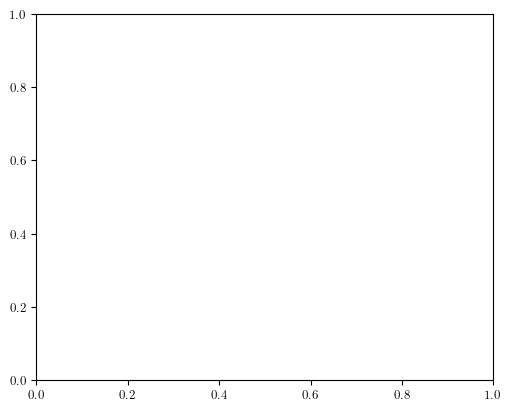

In [47]:
%matplotlib inline
param = pybamm.ParameterValues('Tran2023')
A_surf = param["Active material surface area [m2]"]
P_atm = param["Atmospheric pressure [kPa]"]
thermal = pybamm.thermal_parameters
V_head_0 = param.evaluate(thermal.V_head_0)
A_surf = param.evaluate(thermal.A_surf)
L = param.evaluate(thermal.L_poron)
E = param.evaluate(thermal.E_poron)
alpha_cell = param.evaluate(thermal.alpha_cell)
T_amb = param["Ambient temperature [K]"]
# T_amb = data.Temp[0]
t = np.array(data.t)

# n_CO2 = solution["Amount of CO2 generated [mol]"].entries #mol
P_elyte = solution["Electrolyte gas saturation pressure [kPa]"].entries
P_gas = solution["Total gas pressure [kPa]"].entries
P_co2 = solution["CO2 gas pressure [kPa]"].entries #- sigma_0
# P_gas = P_elyte + P_co2 #- sigma_0 - P_atm
Vh = solution["Headspace volume [m3]"].entries

F0s = [data.F[0]]
fig, ax = plt.subplots(1,  1, figsize=(5, 4), constrained_layout=True)
ax.plot(t, P_gas, 'k', label = 'PyBaMM: P$_{\mathrm{gas}}$')
# ax.plot(t, P_co2, '--k', label = 'PyBaMM: P$_{\mathrm{co2}}$')

ax2 = ax.twinx()
ax2.plot(t, Vh, ':k', label = 'PyBaMM: V$_{\mathrm{g}}$')

for F0 in F0s:
    sigma_0 = F0/A_surf/1000
    delta_sigma_calc = P_elyte - sigma_0 - P_atm  #kPa

    # calculate Vg
    b = V_head_0 + A_surf*L/E*(delta_sigma_calc) - A_surf*alpha_cell*(data.Temp+273.15-T_amb)
    c = A_surf*L/E*n_CO2*(constants.R/1000)*(data.Temp+273.15)
    Vg_calc = (b+np.sqrt(b**2+4*c))/2
    Vg = np.array([max(Vg_calc0, V_head_0) for Vg_calc0 in Vg_calc]) # min Vg = V_head_0
    # Vg = (b+np.sqrt(b**2+4*c))/2

    # calculate P_gas
    # P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vh) # using Vh from sim
    P_CO2_calc = (n_CO2*(constants.R/1000)*(data.Temp+273.15)/Vg) 
    P_gas_calc = P_elyte + P_CO2_calc
    
    # plot
    t = np.array(data.t)
    ax.plot(t, P_gas_calc,'--r', label = "AS: P$_\mathrm{{gas}}$ (" + str(np.round(F0)) + "N)") #  (F$_0$ = " + str(np.round(F0)) + ")"
    # ax.plot(t, P_CO2_calc,'--r', label = "Analytic soln  P$_\mathrm{{CO2}}$" ) #P_CO2_calc (F$_0$ = " + str(np.round(F0)) + ")")    
    ax2.plot(t, Vg, ':r', label = "AS: Vg (" + str(np.round(F0)) + "N)")
    ax2.set_ylabel('V$_{\mathrm{gas}}$ [m$^3$]')
    # ax2.set_ylim([0,5e-3])



ax.set_xlabel('Time [s]')
ax.set_ylabel('P$_{\mathrm{gas}}$ [kPa]')
# ax.set_ylim([0, 225])
# ax.legend() #loc = 'upper center'
ax2.legend(loc = 'lower right') #

In [8]:
def sim_venting(k_A, t, T_in, T_amb_0, params={}):
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    
    if np.isnan(F0):
        P0_sim =  data['F'].iloc[0]/param['Active material surface area [m2]']/1000
    else:
        P0_sim = F0/param['Active material surface area [m2]']/1000
    param.update({
        "Initial fraction of Li in SEI": 0.15, #*k_sei,
        "Frequency factor for SEI decomposition [s-1]": 1.67E15*k_A,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [ m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Initial cell compression stress [kPa]": P0_sim,
        # "Critical venting pressure [kPa]": max(158.7731,(max(data['F']) )/param['Active material surface area [m2]']/1000 + 101)
        
    }, check_already_exists = False)

    param.update(params, check_already_exists = False)

    # Define input and output
    T_vol_av = pybamm.Variable("Volume-averaged cell temperature [K]")
    x_sei = pybamm.Variable("Fraction of Li in SEI")
    delta_sigma = pybamm.Variable("Cell expansion stress [kPa]")

    # Init model and variables
    model = pybamm.BaseModel()
    model.variables = {
        "Volume-averaged cell temperature [K]": T_vol_av,
        "Fraction of Li in SEI": x_sei,
        "Cell expansion stress [kPa]": delta_sigma,
    }
    model.external_variables = [T_vol_av]

    # Set up parameters
    thermal = pybamm.thermal_parameters
    k_b = constants.k_b

    r_sei_dimensional = (
        -param.evaluate(thermal.A_sei)
        * x_sei
        * pybamm.exp(-param.evaluate(thermal.E_sei) / (k_b * T_vol_av))
    )  # units 1/s

    model.variables.update({
            "SEI decomposition reaction rate [s-1]": r_sei_dimensional,
        })

    # VENTING SUBMODEL
    P_crit = param.evaluate(thermal.P_crit)
    m_an = param.evaluate(thermal.m_an)
    x_sei_0 = param.evaluate(thermal.x_sei_0)
    M_C6 = param.evaluate(thermal.M_an)
    V_head_0 = param.evaluate(thermal.V_head_0)
    A_surf = param.evaluate(thermal.A_surf)
    L = param.evaluate(thermal.L_poron)
    E = param.evaluate(thermal.E_poron)
    alpha_cell = param.evaluate(thermal.alpha_cell)
    sigma_0 = param.evaluate(thermal.sigma_0)
    P_atm = param.evaluate(thermal.P_atm)
    delta_d = L/E*delta_sigma
    T_amb = T_amb_0 +273.15 # param.evaluate(thermal.T_amb_dim(0)) #no effect on venting
    delta_T = T_vol_av-T_amb
    V_head = V_head_0 + A_surf*(delta_d-alpha_cell*delta_T)   
    P_sat_e = P_sat(T_vol_av)
    n_CO2 = m_an*(x_sei_0 - x_sei)/(2*M_C6)
    P_CO2 = n_CO2*constants.R*T_vol_av/V_head/1000 #pybamm.minimum(n_CO2*constants.R*T_vol_av/V_head/1000, P_crit*2) #kPa
    P_gas =  P_CO2 + P_sat_e 

    model.variables.update({
        "Thermal expansion stress of active material [kPa]": E*alpha_cell*delta_T/L,
        "Electrolyte gas saturation pressure [kPa]": P_sat_e,
        "CO2 gas pressure [kPa]": P_CO2,
        "Total gas pressure [kPa]": P_gas,
        "Amount of CO2 generated [mol]": n_CO2,
        "Headspace volume [m3]": V_head,
    })

    # RHS
    model.rhs = {
        x_sei: r_sei_dimensional,
    }
    model.algebraic = {
        delta_sigma: delta_sigma - pybamm.maximum(P_gas-P_atm-sigma_0, E*alpha_cell*delta_T/L),
        }

    # set initial conditions
    model.initial_conditions = {
        x_sei: param.evaluate(thermal.x_sei_0),
        delta_sigma: pybamm.Scalar(0),
        }

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # solve
    sim = pybamm.Simulation(model)

    for i,T in enumerate(T_in[0:-1]+273.15):
        dt = t[i+1]-t[i]
        external_variables = {"Volume-averaged cell temperature [K]": T}
        sim.step(dt, external_variables=external_variables)

    return sim

# PLOT: Simulation 

# Archive